# Decision Tree Classifier for Shopping Preference Prediction

In this notebook we explore Decision Trees, a powerful and highly interpretable machine learning model used for classification and regression tasks.

Our objective is to predict a customer’s shopping preference:
- Online
- Store
- Hybrid

based on behavioral and purchasing features.

This notebook will cover:
1. Mathematical intuition behind Decision Trees
2. Bias–variance trade-off
3. When to use Decision Trees
4. When not to use Decision Trees
5. Hyperparameter tuning
6. Implementation using Scikit-Learn
7. Model interpretation and feature importance

The notebook integrates the project’s modular machine learning pipeline:
- src/data_loader.py
- src.features.py
- src.preprocess.py

In [69]:
# Setup
import sys
sys.path.append("..")

# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

# Import project modules
from src.data_loader import load_raw_data
from src.preprocess import preprocess_dataset

sns.set(style="whitegrid")

## Load the Dataset

We load the dataset using our centralized project data loader.

In [70]:
dataset_name = "online vs store shopping dataset.csv"

df = load_raw_data(dataset_name)

df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


## Data Preprocessing

The preprocessing pipeline performs:

- Feature engineering
- Handling categorical variables
- Feature scaling
- Train/test split

In [71]:
X_train, X_test, y_train, y_test, preprocessor = preprocess_dataset(
    df,
    target_column="shopping_preference"
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (9431, 34)
Test shape: (2358, 34)


## Encode Target Variable

Decision Trees require numeric labels, so we encode the target variable.

In [72]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Mathematical Intuition of Decision Trees

Decision Trees are **hierarchical models** that recursively split the dataset based on feature values.

The goal is to create **pure nodes** where most samples belong to the same class.

At each split, the algorithm chooses the feature that **maximizes information gain**.

Two common impurity measures are used:

### Gini Impurity

Gini = 1 − Σ(pi²)

Where pi represents the probability of each class.

### Entropy

Entropy = − Σ pi log2(pi)

Lower impurity means better separation between classes.

The tree grows by repeatedly selecting the best split until a stopping condition is reached.

# Bias vs Variance Trade-off

Decision Trees are highly flexible models.

A **deep tree** can perfectly fit the training data but may overfit.

A **shallow tree** may underfit by not capturing enough complexity.

Key factors controlling this trade-off include:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`

Proper tuning of these hyperparameters helps balance **bias and variance**.

# When to Use Decision Trees

Decision Trees are useful when:

✔ Interpretability is important  
✔ Relationships between features are nonlinear  
✔ Both numerical and categorical features exist  
✔ Feature interactions are complex  

Decision Trees are widely used in:

- Customer segmentation
- Fraud detection
- Medical decision systems
- Risk assessment

# When NOT to Use Decision Trees

Decision Trees may struggle in the following scenarios:

❌ Very small datasets  
❌ Highly noisy data  
❌ When small variations in data drastically change splits  

Because Decision Trees are **high-variance models**, they can easily overfit the training data.

In many cases, **ensemble methods like Random Forests or Gradient Boosting perform better**.

## Train a Baseline Model

In [73]:
tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train_enc)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [74]:
pred_enc = tree.predict(X_test)

pred = le.inverse_transform(pred_enc)

## Model Evaluation

In [75]:
print("Accuracy:", accuracy_score(y_test, pred))

print("F1 Score:", f1_score(y_test, pred, average="weighted"))

print("\nClassification Report:\n")

print(classification_report(y_test, pred))

Accuracy: 0.9402035623409669
F1 Score: 0.9399646925141415

Classification Report:

              precision    recall  f1-score   support

      Hybrid       0.30      0.30      0.30        74
      Online       0.83      0.80      0.82       235
       Store       0.98      0.98      0.98      2049

    accuracy                           0.94      2358
   macro avg       0.70      0.69      0.70      2358
weighted avg       0.94      0.94      0.94      2358



## Confusion Matrix

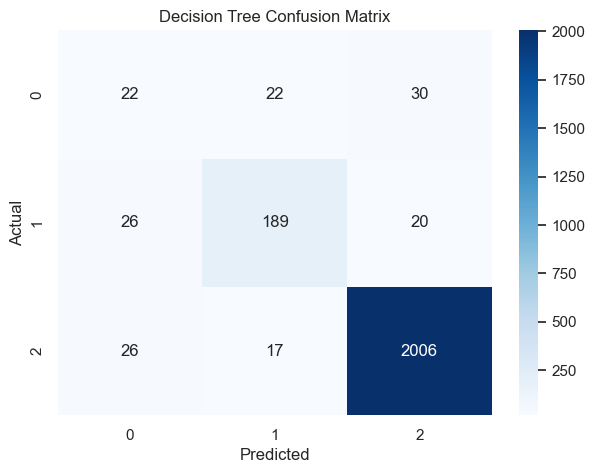

In [76]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")

plt.ylabel("Actual")

plt.xlabel("Predicted")

plt.show()

# Hyperparameter Tuning

Important Decision Tree parameters:

| Parameter | Description |
|------|------|
|max_depth| Maximum tree depth |
|min_samples_split| Minimum samples required to split |
|min_samples_leaf| Minimum samples per leaf |
|criterion| Impurity metric |

In [77]:
param_grid = {
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,5],
    "criterion": ["gini","entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train_enc)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [78]:
best_tree = grid.best_estimator_

pred_enc = best_tree.predict(X_test)

pred = le.inverse_transform(pred_enc)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

      Hybrid       0.31      0.32      0.32        74
      Online       0.87      0.83      0.85       235
       Store       0.98      0.98      0.98      2049

    accuracy                           0.94      2358
   macro avg       0.72      0.71      0.71      2358
weighted avg       0.95      0.94      0.94      2358



# Feature Importance

Decision Trees provide **feature importance scores**, indicating how much each feature contributes to prediction.

In [79]:
importances = best_tree.feature_importances_

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
10,num__avg_store_spend,0.675153
22,num__online_order_ratio,0.073819
25,num__digital_engagement_score,0.069949
18,num__need_touch_feel_score,0.058097
5,num__online_payment_trust_score,0.021979
6,num__tech_savvy_score,0.018822
16,num__product_availability_online,0.010342
4,num__social_media_hours,0.007546
14,num__delivery_fee_sensitivity,0.007479
29,num__offline_shopping_preference_score,0.007216


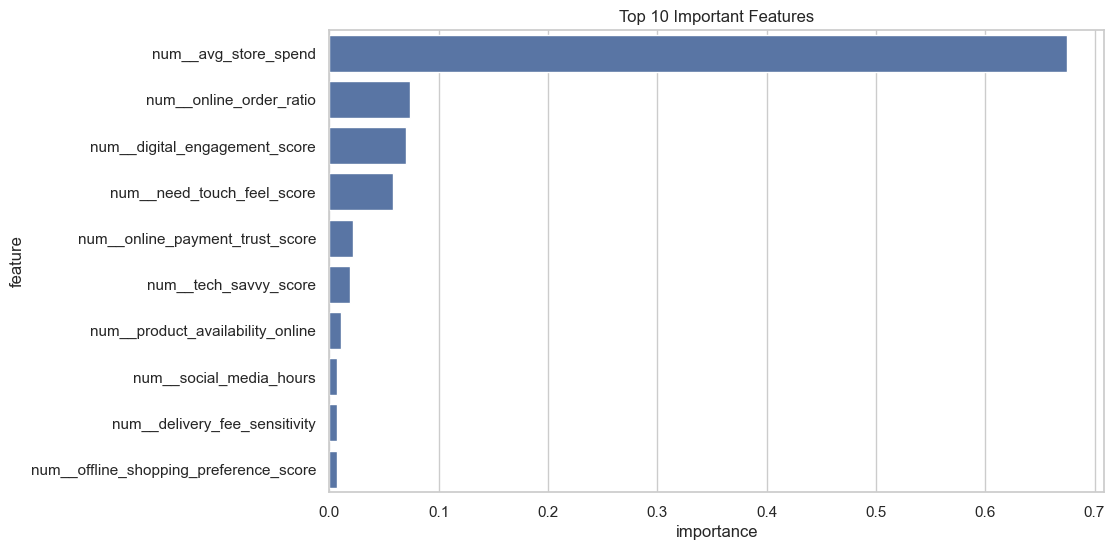

In [80]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Visualizing the Decision Tree

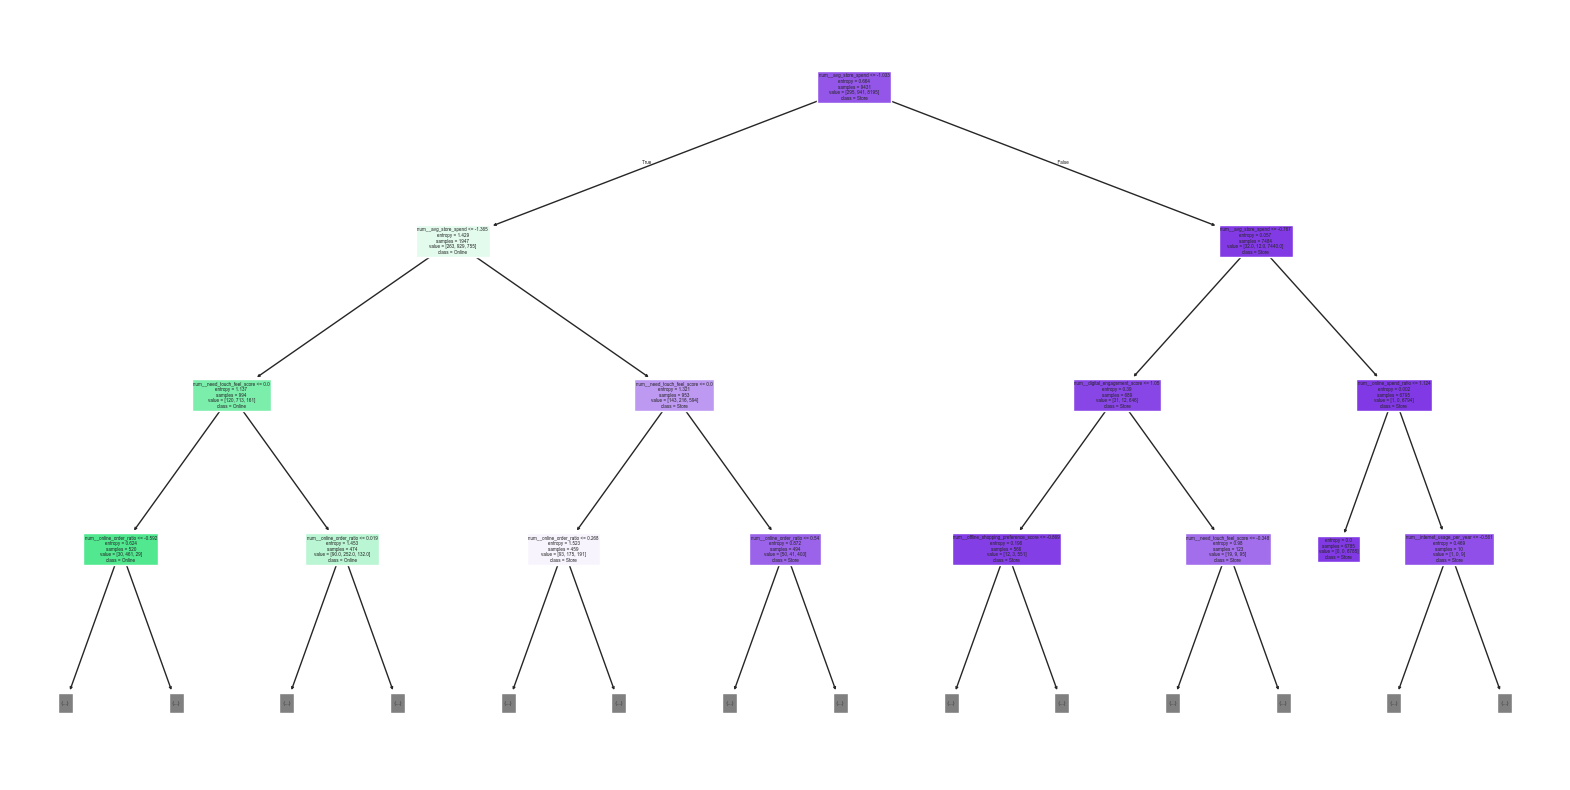

In [81]:
feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(20,10))

plot_tree(
    best_tree,
    filled=True,
    feature_names=feature_names,
    class_names=le.classes_,
    max_depth=3
)

plt.show()

# Key Insights

Decision Trees allow us to understand **how customer behavior drives shopping preferences**.

The model identifies decision rules such as:

- customers with high online spending → Online preference
- customers with strong in-store interaction → Store preference

This interpretability makes Decision Trees valuable for **business insights**.

# Next Models to Explore

Next models in the machine learning pipeline:

- Random Forest
- Gradient Boosting
- Naive_Bayes

These **ensemble models combine multiple trees** to improve predictive performance.